In [1]:
from pathlib import Path

import equinox as eqx
import grain
import jax
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from context_flux_no.data.sources import ZarrWellDatasetSource
from context_flux_no.training.io import load_model
from matplotlib.colors import TwoSlopeNorm
from tqdm import tqdm


jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [17]:
import colorcet as cc


DISPLAY_NAME = {"HyperNeuralOperator": "HFluxNO", "DPOT": "DPOT", "DISCO": "DISCO"}
MODEL_ORDER = ["HyperNeuralOperator", "DPOT", "DISCO"]  # keys of u_pred_dict
RC = {
    "figure.figsize": (30, 10),
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "pdf.fonttype": 42,
}
FIELD_LABEL = {
    "rho": "Density " + r"$\rho$",
    "rho_e": "Internal energy density " + r"$\rho e$",
    "p": "Pressure " + r"$p$",
    "speed": "Speed " + r"$|\mathbf{v}|$",
}
FIELD_CMAP = {"rho": cc.cm.fire, "rho_e": cc.cm.bmy, "p": "cividis", "speed": cc.cm.kbc}


# ------------------------------------------------------------ helpers
def primitives(q: np.ndarray, gamma: float | None = None) -> dict:
    """q: (..., 4, Nx, Ny) conserved -> rho, |v|, internal energy density
    rho*e = E - 0.5*rho*|v|^2, and p = (gamma-1)*rho*e if gamma is given.
    rho*e needs no gamma and equals p up to the per-trajectory constant
    (gamma-1), so it shows the same structure as the pressure field."""
    rho, E, mx, my = q[..., 0, :, :], q[..., 1, :, :], q[..., 2, :, :], q[..., 3, :, :]
    u, v = mx / rho, my / rho
    rho_e = E - 0.5 * rho * (u**2 + v**2)
    out = {"rho": rho, "rho_e": rho_e, "speed": np.sqrt(u**2 + v**2)}
    if gamma is not None:
        out["p"] = (gamma - 1.0) * rho_e
    return out


def grad_mag_periodic(f: np.ndarray, dx: float) -> np.ndarray:
    """|grad f| by 2nd-order central differences with periodic wrap; f: (..., Nx, Ny)."""
    gx = (np.roll(f, -1, axis=-2) - np.roll(f, 1, axis=-2)) / (2 * dx)
    gy = (np.roll(f, -1, axis=-1) - np.roll(f, 1, axis=-1)) / (2 * dx)
    return np.sqrt(gx**2 + gy**2)


def schlieren(
    rho: np.ndarray, dx: float, g_ref: float, kappa: float = 15.0
) -> np.ndarray:
    """exp(-kappa |grad rho| / g_ref): 1 in smooth flow, -> 0 at shocks."""
    return np.exp(-kappa * grad_mag_periodic(rho, dx) / g_ref)


def _tile(ax, img, **kw):
    im = ax.imshow(img, interpolation="nearest", **kw)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.4)
    return im


def _cbar(fig, axes_col, im, label=None):
    """Colourbar spanning a vertical run of axes (list, top to bottom)."""
    top, bot = axes_col[0].get_position(), axes_col[-1].get_position()
    cax = fig.add_axes([top.x1 + 0.012, bot.y0, 0.012, top.y1 - bot.y0])
    cb = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(length=2, width=0.4)
    if label:
        cb.set_label(label)
    return cb


def _gamma(gammas, i):
    return float(gammas) if np.isscalar(gammas) else float(gammas[i])


def _err_limit(u_data, u_pred_dict, i, t_idxs, q=99.0):
    """Symmetric limit for normalised signed rho error, from the worst model."""
    rho_ref = u_data[i, t_idxs, 0]
    scale = np.abs(rho_ref).max()
    return max(
        np.percentile(np.abs((u_pred_dict[m][i, t_idxs, 0] - rho_ref) / scale), q)
        for m in MODEL_ORDER
    ), scale


# ------------------------------------------------------------ main-text row
def fig_main(u_data, u_pred_dict, i, t_idxs, dt, dx, out=None, floor=1e-2, cmap=None):
    """Main-text row: rows = times, cols = reference + models; each panel is
    the density-gradient magnitude |grad rho| / G_ref on a log scale
    (numerical schlieren in colour).  G_ref = max |grad rho| of the reference
    over the shown times, shared by every panel; values below `floor` are
    clipped so smooth flow is uniformly dark and fronts glow.
    Two times (e.g. the context length and twice it) make a balanced 2 x 4."""
    cmap = cmap or FIELD_CMAP["rho_e"]  # bmy: dark blue -> yellow
    g_ref = max(grad_mag_periodic(u_data[i, t, 0], dx).max() for t in t_idxs)
    cols = ["reference"] + MODEL_ORDER
    with mpl.rc_context(RC):
        fig, axes = plt.subplots(
            len(t_idxs),
            4,
            figsize=(5.5, 1.3 * len(t_idxs) + 0.25),
            gridspec_kw={"wspace": 0.04, "hspace": 0.06, "right": 0.9},
        )
        axes = np.atleast_2d(axes)

        g_all = (
            np.concatenate(
                [grad_mag_periodic(u_data[i, t, 0], dx).ravel() for t in t_idxs]
            )
            / g_ref
        )
        lo, hi = np.log10(np.percentile(g_all, [50, 99.5]))

        for r, t in enumerate(t_idxs):
            for c, name in enumerate(cols):
                rho = (
                    u_data[i, t, 0]
                    if name == "reference"
                    else u_pred_dict[name][i, t, 0]
                )
                g = np.maximum(grad_mag_periodic(rho, dx) / g_ref, floor)
                im = _tile(axes[r, c], np.log10(g), cmap=cmap, vmin=lo, vmax=hi)
                if r == 0:
                    axes[r, c].set_title("reference" if c == 0 else DISPLAY_NAME[name])
                if c == 0:
                    axes[r, c].set_ylabel(
                        rf"$t = {(t + 1) * dt:.3g}$" + f"\n({t + 1} steps)",
                        rotation=0,
                        ha="right",
                        va="center",
                        labelpad=6,
                    )
        cb = _cbar(
            fig,
            [axes[0, -1], axes[-1, -1]],
            im,
            r"$\log_{10}\,|\nabla\rho|/\max|\nabla\rho|$",
        )
        if out:
            fig.savefig(out, bbox_inches="tight", pad_inches=0.02)
        return fig


# ------------------------------------------------------------ appendix A
def fig_field(u_data, u_pred_dict, i, t_idxs, dt, field="rho", out=None, gammas=None):
    """One field: rows = reference + models (same order as fig_errors),
    columns = times, one colour scale from the reference over the shown times."""
    g = None if gammas is None else _gamma(gammas, i)
    ref = primitives(u_data[i], g)[field]
    preds = {m: primitives(u_pred_dict[m][i], g)[field] for m in MODEL_ORDER}
    rows = [("Reference", ref)] + [(DISPLAY_NAME[m], preds[m]) for m in MODEL_ORDER]
    vmin, vmax = np.percentile(ref[t_idxs], [0.5, 99.5])
    with mpl.rc_context(RC):
        fig, axes = plt.subplots(
            len(rows),
            len(t_idxs),
            figsize=(5.5, 1.2 * len(rows) + 0.25),
            gridspec_kw={"wspace": 0.04, "hspace": 0.06, "right": 0.9},
        )
        for r, (lab, arr) in enumerate(rows):
            for c, t in enumerate(t_idxs):
                im = _tile(
                    axes[r, c], arr[t], cmap=FIELD_CMAP[field], vmin=vmin, vmax=vmax
                )
                if r == 0:
                    axes[r, c].set_title(rf"$t = {(t + 1) * dt:.3g}$")
                if c == 0:
                    axes[r, c].set_ylabel(
                        lab, rotation=0, ha="right", va="center", labelpad=6
                    )
        _cbar(fig, [axes[0, -1], axes[-1, -1]], im, FIELD_LABEL[field])
        if out:
            fig.savefig(out, bbox_inches="tight", pad_inches=0.02, dpi=600)
        return fig


# ------------------------------------------------------------ appendix B
def fig_errors(u_data, u_pred_dict, i, t_idxs, dt, out=None, lim=None):
    """Rows = models, columns = times, signed rho error, one shared scale."""
    lim_auto, scale = _err_limit(u_data, u_pred_dict, i, t_idxs)
    lim = lim or lim_auto
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    with mpl.rc_context(RC):
        fig, axes = plt.subplots(
            len(MODEL_ORDER),
            len(t_idxs),
            figsize=(5.5, 1.2 * len(MODEL_ORDER) + 0.25),
            gridspec_kw={"wspace": 0.04, "hspace": 0.06, "right": 0.9},
        )
        for r, m in enumerate(MODEL_ORDER):
            for c, t in enumerate(t_idxs):
                err = (u_pred_dict[m][i, t, 0] - u_data[i, t, 0]) / scale
                im = _tile(axes[r, c], err, cmap=cc.cm.coolwarm, norm=norm)
                if r == 0:
                    axes[r, c].set_title(rf"$t = {(t + 1) * dt:.3g}$")
                if c == 0:
                    axes[r, c].set_ylabel(
                        DISPLAY_NAME[m], rotation=0, ha="right", va="center", labelpad=6
                    )
        _cbar(fig, [axes[0, -1], axes[-1, -1]], im, r"$(\hat\rho-\rho)/\max|\rho|$")
        if out:
            fig.savefig(out, bbox_inches="tight", pad_inches=0.02, dpi=600)
        return fig

In [2]:
checkpoint_dir = Path("../../checkpoints/euler_2d/")

model_paths = {
    "DPOT": "seed=0/26-09-22-02_45_52",
    # "HyperFluxFNOLocal": "seed=10/26-04-30-01:34:48",
    # "DISCO": "seed=0/26-07-18-20:51:57",
    "HyperNeuralOperator": "seed=0/26-09-22-13_04_48",
    "DISCO": "seed=0/26-09-22-02_32_26",
}

In [5]:
source = ZarrWellDatasetSource(
    "../../data/datasets",
    "euler_2d",
    "test",
    exclude_filters=[
        "step",
    ],
    window_size=100,
    # preload_into_ram=True,
)


dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('rho', 'E'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1


In [6]:
dataloader = grain.DataLoader(
    data_source=source,
    sampler=grain.samplers.IndexSampler(len(source), shuffle=False, seed=0),
    operations=[grain.transforms.Batch(batch_size=64)],
    worker_count=0,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)

In [7]:
dataiter = iter(dataloader)
batch = next(dataiter)

In [8]:
def get_loss_args(source):
    dt = source.metadata_common["temporal_resolution"]
    dxs = source.metadata_common["spatial_resolution"]
    return (dt, *dxs)

In [9]:
u_pred_dict = {}

for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / path)
    model = eqx.nn.inference_mode(model, True)

    context, u_data = batch[:, :20], batch[:, 20:]
    u_pred = eqx.filter_vmap(
        lambda x, y: model.rollout(x, get_loss_args(source), num_steps=len(y))[0]
    )(context, u_data)

    u_pred_dict[model_type] = u_pred

 33%|███▎      | 1/3 [00:23<00:46, 23.43s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/utils.py:73: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x1479335fa540> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeEr

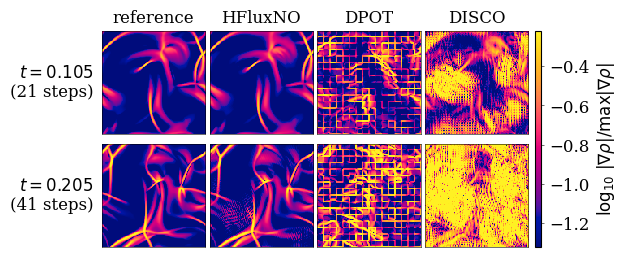

In [19]:
i = 27
fig = fig_main(
    u_data,
    u_pred_dict,
    i,
    [20, 40],
    source.metadata_common["temporal_resolution"],
    source.metadata_common["spatial_resolution"][0],
)
fig

In [8]:
import jax.numpy as jnp
from context_flux_no.metrics import relative_L2_error


err_time_dict = jax.tree.map(
    lambda x: jnp.mean(
        eqx.filter_vmap(eqx.filter_vmap(relative_L2_error))(x[:,], u_data[:,]), axis=0
    ),
    u_pred_dict,
)

[0.0069098  0.01410954 0.02187678 0.03013267 0.03872815 0.04747627
 0.05628639 0.06510963 0.0739167  0.08282773 0.09195948 0.10139532
 0.11129676 0.12192673 0.1335622  0.14632852 0.16017848 0.17492603
 0.19034022 0.20616302 0.22215432 0.23815718 0.25418764 0.27036202
 0.28674394 0.30351427 0.32083648 0.33891368 0.35794476 0.3780828
 0.39955395 0.42243665 0.44689605 0.4730215  0.5009651  0.53081775
 0.5626066  0.5962563  0.6314477  0.66800123 0.7057408  0.7445904
 0.7845967  0.8258821  0.8683836  0.9122292  0.95766735 1.0049165
 1.0540013  1.1049783  1.1577982  1.2124991  1.269203   1.3279948
 1.3888402  1.451745   1.516884   1.5843902  1.6544533  1.727253
 1.8029654  1.8818991  1.964261   2.0501761  2.1398544  2.2334967
 2.3313189  2.433598   2.5407085  2.6530585  2.7709334  2.8948486
 3.0253084  3.1627889  3.3074021  3.4593084  3.618742   3.7861938
 3.962166   4.147086  ]
[0.00896319 0.01500892 0.02459659 0.03692982 0.0515977  0.06836626
 0.08695768 0.1070485  0.1284431  0.15088268 0.

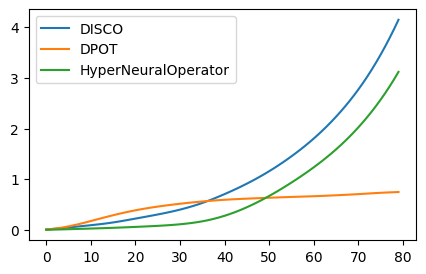

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
for model, err_t in err_time_dict.items():
    print(err_t)
    ax.plot(err_t, label=model)
ax.legend()

In [10]:
jax.tree.map(
    lambda x: eqx.filter_vmap(relative_L2_error)(x[:,], u_data[:,]).shape,
    u_pred_dict,
)

{'DISCO': (64,), 'DPOT': (64,), 'HyperNeuralOperator': (64,)}

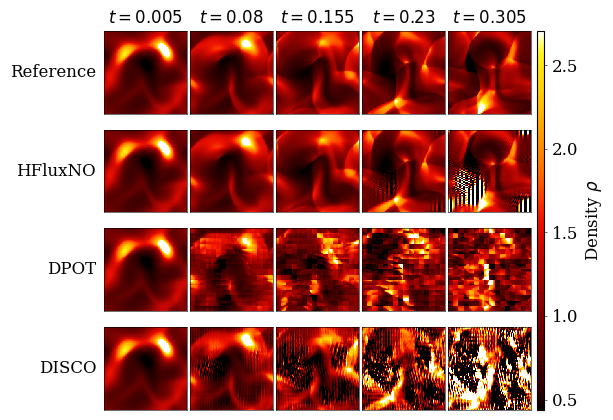

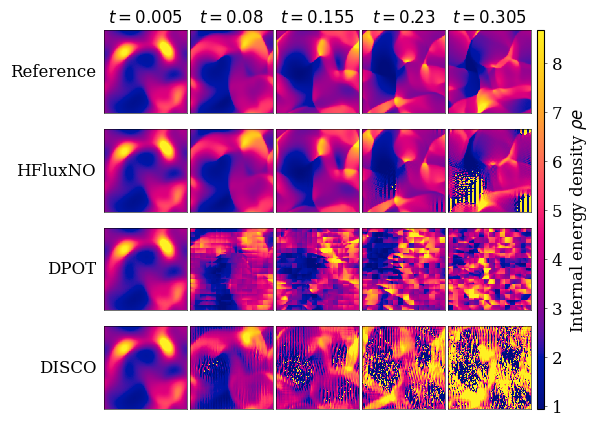

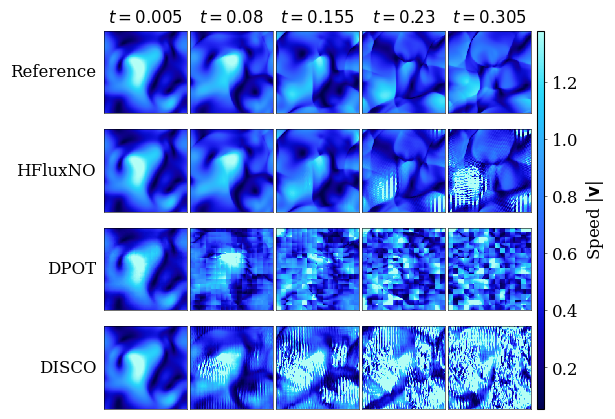

In [12]:
i = 27
for field in ("rho", "rho_e", "speed"):
    fig = fig_field(
        u_data,
        u_pred_dict,
        i,
        [0, 15, 30, 45, 60],
        source.metadata_common["temporal_resolution"],
        field=field,
        out=f"../../figures/euler_2d_id_{i}_{field}.pdf",
    )

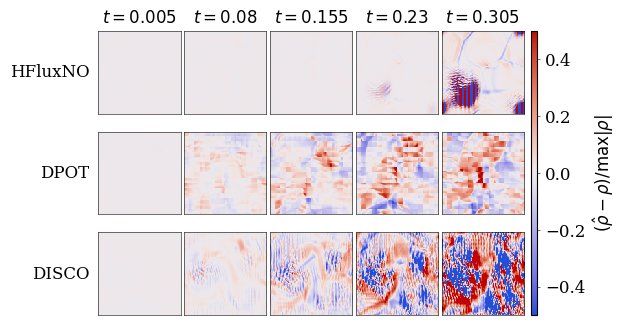

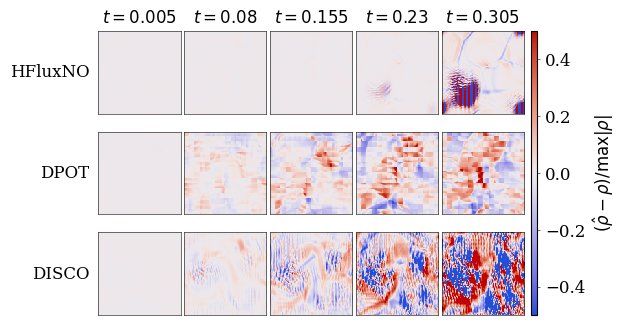

In [13]:
fig = fig_errors(
    u_data,
    u_pred_dict,
    i,
    [0, 15, 30, 45, 60],
    source.metadata_common["temporal_resolution"],
    lim=0.5,
    out=f"../../figures/euler_2d_id_{i}_error.pdf",
)
fig

## OOD

In [14]:
source = ZarrWellDatasetSource(
    "../../data/datasets",
    "euler_2d",
    "test",
    exclude_filters=[
        "grf",
    ],
    window_size=100,
    # preload_into_ram=True,
)


dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('rho', 'E'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1


In [15]:
source.datapaths

[PosixPath('/home/jhko725/projects/CONTEXT_FLUX_NO/data/datasets/euler_2d/data/test/euler_2d_step_seed=0.zarr')]

In [16]:
dataloader = grain.DataLoader(
    data_source=source,
    sampler=grain.samplers.IndexSampler(len(source), shuffle=True, seed=0),
    operations=[grain.transforms.Batch(batch_size=64)],
    worker_count=0,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)
dataiter = iter(dataloader)
batch = next(dataiter)

In [17]:
batch[0].shape

(100, 4, 128, 128)

In [18]:
u_pred_dict = {}

for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / path)
    model = eqx.nn.inference_mode(model, True)

    context, u_data = batch[:, :20], batch[:, 20:]
    u_pred = eqx.filter_vmap(
        lambda x, y: model.rollout(x, get_loss_args(source), num_steps=len(y))[0]
    )(context, u_data)

    u_pred_dict[model_type] = u_pred

 33%|███▎      | 1/3 [00:08<00:16,  8.03s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/utils.py:73: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
 67%|██████▋   | 2/3 [00:16<00:08,  8.46s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|██████████| 3/3 [00:56<00:00, 18.69s/it]


In [19]:
u_data.shape

(64, 80, 4, 128, 128)

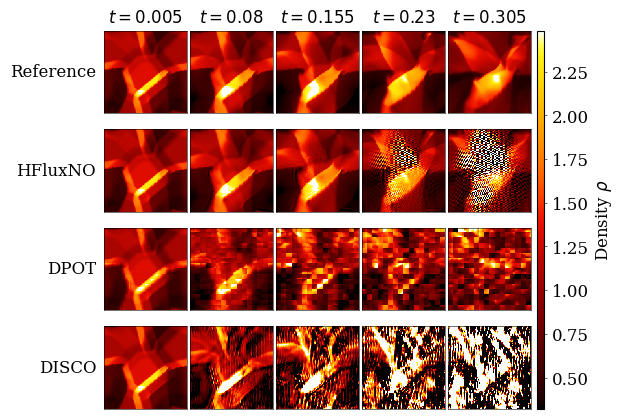

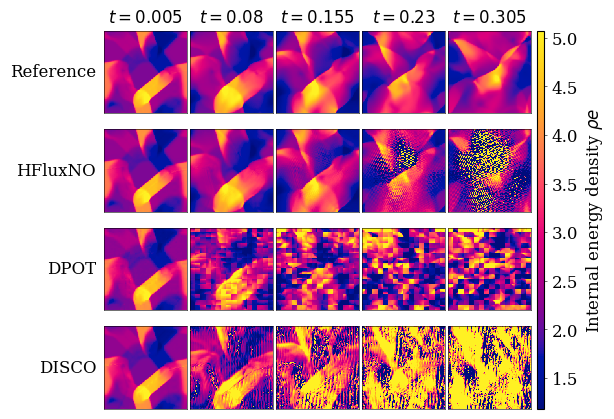

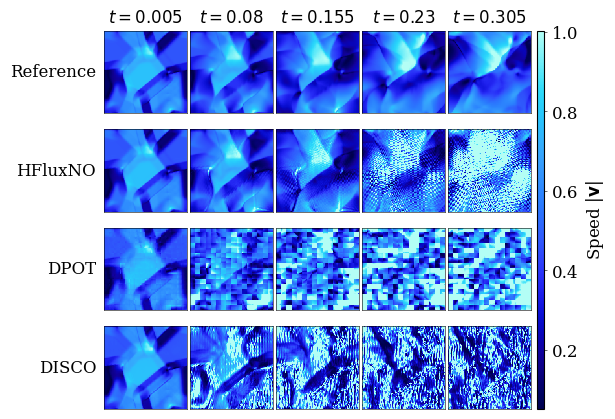

In [20]:
i = 43
for field in ("rho", "rho_e", "speed"):
    fig = fig_field(
        u_data,
        u_pred_dict,
        i,
        [0, 15, 30, 45, 60],
        source.metadata_common["temporal_resolution"],
        field=field,
        out=f"../../figures/euler_2d_ood_{i}_{field}.pdf",
    )

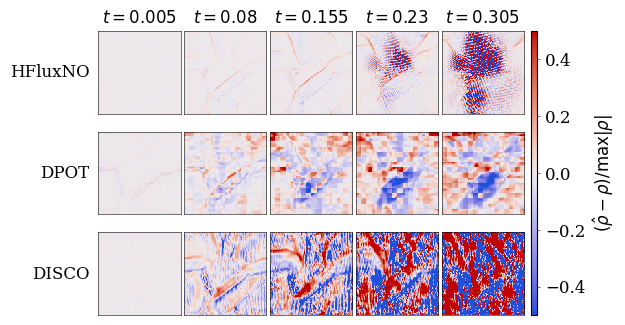

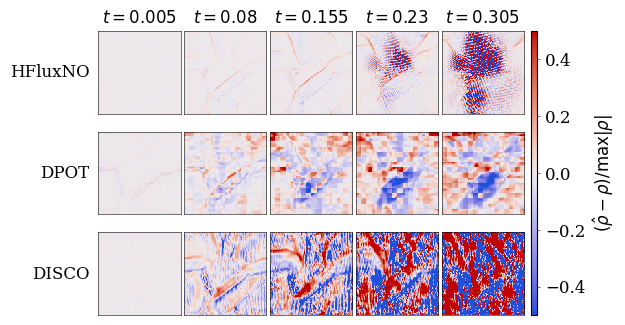

In [21]:
fig = fig_errors(
    u_data,
    u_pred_dict,
    i,
    [0, 15, 30, 45, 60],
    source.metadata_common["temporal_resolution"],
    lim=0.5,
    out=f"../../figures/euler_2d_ood_{i}_error.pdf",
)
fig

In [22]:
u_data.shape

(64, 80, 4, 128, 128)